# Pressure-Dependent Rate Constants (PLOG)

This tutorial demonstrates how to use KiRATE's `Plog` class to compute pressure and temperature-dependent rate constants for gas-phase chemical reactions. The PLOG formulation provides a flexible representation for reactions whose rates vary significantly with both temperature and pressure.

In [1]:
# --------------------------------------------------------
# External packages
import jax.numpy as jnp
import matplotlib.pyplot as plt

# --------------------------------------------------------
# KiRATE modules
from KiRATE.kinetics import Plog

## Theory

The PLOG (Pressure-dependent Logarithmic) formulation represents rate constants at discrete pressure levels using modified Arrhenius equations, then interpolates between them.

### Rate Constants at Pressure Levels

At each specified pressure $P_i$, the rate constant follows the modified Arrhenius form:

$$k(T, P_i) = A_i \cdot T^{n_i} \cdot \exp\left(-\frac{E_{a,i}}{RT}\right)$$

where:
- $k(T, P_i)$ = rate constant at pressure level $P_i$
- $A_i$ = pre-exponential factor at pressure $P_i$
- $n_i$ = temperature exponent at pressure $P_i$
- $E_{a,i}$ = activation energy at pressure $P_i$ [cal/mol]
- $R$ = universal gas constant [cal/(mol·K)]

### Pressure Interpolation

For any pressure $P$ between $P_i$ and $P_{i+1}$, KiRATE performs **logarithmic interpolation**:

$$\ln k(T, P) = \ln k(T, P_i) + \frac{\ln P - \ln P_i}{\ln P_{i+1} - \ln P_i} \left[\ln k(T, P_{i+1}) - \ln k(T, P_i)\right]$$

**Key Features:**
- Interpolation in log-log space (more physically realistic)
- Extrapolation bounded by $P_{\min}$ and $P_{\max}$
- Each pressure level can have different Arrhenius parameters

---

## Creating PLOG Objects

KiRATE supports two methods for initializing PLOG rate constants:

### 1. From Python Dictionary

```python
reaction = Plog(
    name="OH+NO=HONO",
    parameters={
        0.01:  {"A": 5.02e+21, "n": -4.24, "Ea": 898.9},
        0.1:   {"A": 5.31e+22, "n": -4.24, "Ea": 1184.0},
        # ... more pressure levels
    }
)
```

### 2. From CHEMKIN Format String

The CHEMKIN format lists each pressure level with its Arrhenius parameters:

```
REACTION_NAME    A_dummy  n_dummy  Ea_dummy
 PLOG / P1  A1  n1  Ea1 /
 PLOG / P2  A2  n2  Ea2 /
 ...
```

**Note:** The first line contains dummy Arrhenius parameters (typically zeros) that are not used.

In [2]:
# --------------------------------------------------------
# Construction from Python dictionary
reaction = Plog(
    name="OH+NO=HONO",
    parameters={
        0.01: {"A": 5.02e21, "n": -4.24, "Ea": 898.9},
        0.1: {"A": 5.31e22, "n": -4.24, "Ea": 1184.0},
        0.316: {"A": 1.38e23, "n": -4.22, "Ea": 1376.0},
        1.0: {"A": 3.09e23, "n": -4.17, "Ea": 1621.0},
        3.16: {"A": 5.45e23, "n": -4.09, "Ea": 1911.0},
        10.0: {"A": 6.35e23, "n": -3.97, "Ea": 2222.0},
        31.6: {"A": 3.68e23, "n": -3.75, "Ea": 2501.0},
        100.0: {"A": 7.29e22, "n": -3.41, "Ea": 2660.0},
    },
)

# --------------------------------------------------------
# Construction from CHEMKIN-formatted string
reaction = Plog.from_chemkin(
    """
    OH+NO=HONO		0.00000E+00 0.00000E+00 0.00000E+00
     PLOG / 1.00000E-02	5.02000E+21 -4.24000E+00 8.98900E+02 /
     PLOG / 1.00000E-01	5.31000E+22 -4.24000E+00 1.18400E+03 /
     PLOG / 3.16000E-01	1.38000E+23 -4.22000E+00 1.37600E+03 /
     PLOG / 1.00000E+00	3.09000E+23 -4.17000E+00 1.62100E+03 /
     PLOG / 3.16000E+00	5.45000E+23 -4.09000E+00 1.91100E+03 /
     PLOG / 1.00000E+01	6.35000E+23 -3.97000E+00 2.22200E+03 /
     PLOG / 3.16000E+01	3.68000E+23 -3.75000E+00 2.50100E+03 /
     PLOG / 1.00000E+02	7.29000E+22 -3.41000E+00 2.66000E+03 /
    """
)

# --------------------------------------------------------
# Object inspection
print("Detailed representation:")
print(repr(reaction))
print("\nCHEMKIN format:")
print(str(reaction))
print(f"\nNumber of pressure levels: {reaction.num_p_levels}")

Detailed representation:
Plog(
 name = OH+NO=HONO
 num_p_levels = 8
 pressure_levels = [
  P = 1.00000e-02 atm:
   Arrhenius(
    name = OH+NO=HONO (0.01, term 1)
    A    = 5.02000e+21
    n    = -4.24000e+00
    Ea   = 8.98900e+02
   )
  P = 1.00000e-01 atm:
   Arrhenius(
    name = OH+NO=HONO (0.1, term 1)
    A    = 5.31000e+22
    n    = -4.24000e+00
    Ea   = 1.18400e+03
   )
  P = 3.16000e-01 atm:
   Arrhenius(
    name = OH+NO=HONO (0.316, term 1)
    A    = 1.38000e+23
    n    = -4.22000e+00
    Ea   = 1.37600e+03
   )
  P = 1.00000e+00 atm:
   Arrhenius(
    name = OH+NO=HONO (1.0, term 1)
    A    = 3.09000e+23
    n    = -4.17000e+00
    Ea   = 1.62100e+03
   )
  P = 3.16000e+00 atm:
   Arrhenius(
    name = OH+NO=HONO (3.16, term 1)
    A    = 5.45000e+23
    n    = -4.09000e+00
    Ea   = 1.91100e+03
   )
  P = 1.00000e+01 atm:
   Arrhenius(
    name = OH+NO=HONO (10.0, term 1)
    A    = 6.35000e+23
    n    = -3.97000e+00
    Ea   = 2.22200e+03
   )
  P = 3.16000e+01 

## Computing Rate Constants

The `rate_constant(T, P)` method evaluates $k(T, P)$ with full vectorization over both temperature and pressure arrays.

**Broadcasting Behavior:**
- Scalar T, Scalar P → Scalar output
- Vector T, Scalar P → Vector output (length n_T)
- Scalar T, Vector P → Vector output (length n_P)
- Vector T, Vector P → Matrix output (shape: n_P × n_T)

**Key Features:**
- Automatic pressure interpolation in log-log space
- JIT-compiled for performance
- Handles extrapolation at pressure bounds

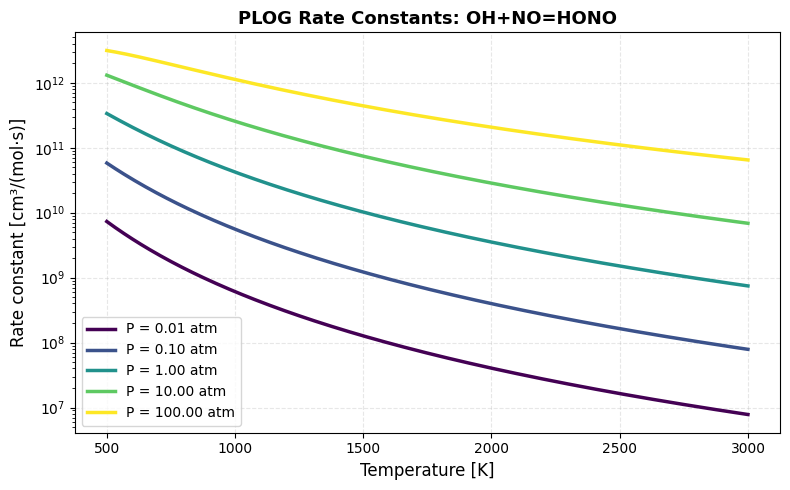


Rate constant at T=1000 K, P=1 atm: 4.224e+10 cm³/(mol·s)


In [3]:
# --------------------------------------------------------
# Define temperature range (500 K to 3000 K)
T_range = jnp.linspace(500, 3000, 300)

# --------------------------------------------------------
# Select representative pressure levels
P_levels = jnp.array([0.01, 0.1, 1.0, 10.0, 100.0])

# --------------------------------------------------------
# Compute rate constants - fully vectorized!
# Returns shape: (n_P, n_T)
k_plog = reaction.rate_constant(T_range, P_levels)

# --------------------------------------------------------
# Visualize temperature dependence at different pressures
fig, ax = plt.subplots(figsize=(8, 5))

colors = plt.cm.viridis(jnp.linspace(0, 1, len(P_levels)))
for i, P in enumerate(P_levels):
    ax.semilogy(T_range, k_plog[i], linewidth=2.5, label=f"P = {P:.2f} atm", color=colors[i])

ax.set_xlabel("Temperature [K]", fontsize=12)
ax.set_ylabel("Rate constant [cm³/(mol·s)]", fontsize=12)
ax.set_title(f"PLOG Rate Constants: {reaction.name}", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

print(f"\nRate constant at T=1000 K, P=1 atm: {reaction.rate_constant(1000.0, 1.0):.3e} cm³/(mol·s)")

## Advanced Features

### Property Access

The `Plog` class provides convenient accessors for pressure-dependent parameters:

| Property | Description | Type |
|----------|-------------|------|
| `name` | Reaction identifier | str |
| `num_p_levels` | Number of discrete pressure levels | int |
| `p_levels` | Array of pressure values | JAX Array |
| `arrhenius_levels` | List of Arrhenius objects at each pressure | list[Arrhenius] |

### Accessing Individual Pressure Levels

Each pressure level is stored as an `Arrhenius` object with its own parameters (A, n, Ea).

In [4]:
# --------------------------------------------------------
# Access stored parameters via properties
print("=" * 70)
print("PLOG STRUCTURE")
print("=" * 70)
print(f"Reaction name:                    {reaction.name}")
print(f"Number of pressure levels:        {reaction.num_p_levels}")
print(f"Pressure levels [atm]:            {[float(p) for p in reaction.p_levels]}")
print("=" * 70)

# --------------------------------------------------------
# Access individual Arrhenius expressions at each pressure
print("\n" + "=" * 70)
print("PARAMETERS AT SELECTED PRESSURE LEVELS")
print("=" * 70)
for i, (P, arrh) in enumerate(zip(reaction.p_levels, reaction.arrhenius_levels)):
    if i in [0, reaction.num_p_levels // 2, reaction.num_p_levels - 1]:  # Show first, middle, last
        print(f"\nP = {float(P):.2e} atm:")
        print(f"  A  = {arrh.A:.3e}")
        print(f"  n  = {arrh.n:.3f}")
        print(f"  Ea = {arrh.Ea:.3e} cal/mol")
print("=" * 70)

# --------------------------------------------------------
# Compare rate constants from PLOG vs individual Arrhenius at a specific pressure
P_compare = 1.0  # atm
T_test = jnp.linspace(500, 3000, 200)

# Get the Arrhenius object at P=1.0 atm
# Find index where pressure level equals 1.0
idx_1atm = int(jnp.argmin(jnp.abs(reaction.p_levels - P_compare)))
arrh_1atm = reaction.arrhenius_levels[idx_1atm]

# Compute rate constants
k_plog_1atm = reaction.rate_constant(T_test, P_compare)
k_arrh_1atm = arrh_1atm.rate_constant(T_test)

# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Direct comparison
ax1.semilogy(T_test, k_plog_1atm, linewidth=2.5, label=f"PLOG at P={P_compare} atm", color="#2E86AB")
ax1.semilogy(
    T_test, k_arrh_1atm, linewidth=2.5, linestyle="--", label=f"Arrhenius at P={P_compare} atm", color="#A23B72"
)
ax1.set_xlabel("Temperature [K]", fontsize=12)
ax1.set_ylabel("Rate constant [cm³/(mol·s)]", fontsize=12)
ax1.set_title(f"PLOG vs Arrhenius at P = {P_compare} atm", fontsize=13, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, linestyle="--")

# Plot 2: Relative difference (should be zero)
rel_diff = jnp.abs(k_plog_1atm - k_arrh_1atm) / k_arrh_1atm * 100
ax2.plot(T_test, rel_diff, linewidth=2.5, color="#F18F01")
ax2.set_xlabel("Temperature [K]", fontsize=12)
ax2.set_ylabel("Relative Difference [%]", fontsize=12)
ax2.set_title("Agreement at Exact Pressure Level", fontsize=13, fontweight="bold")
ax2.grid(True, alpha=0.3, linestyle="--")
# ax2.set_ylim([0, 1e-10])  # Should be essentially zero

plt.tight_layout()
plt.show()

PLOG STRUCTURE
Reaction name:                    OH+NO=HONO
Number of pressure levels:        8
Pressure levels [atm]:            [0.01, 0.1, 0.316, 1.0, 3.16, 10.0, 31.6, 100.0]

PARAMETERS AT SELECTED PRESSURE LEVELS

P = 1.00e-02 atm:


AttributeError: 'list' object has no attribute 'A'

## Logarithmic Interpolation Visualization

The PLOG method interpolates $\ln(k)$ linearly with respect to $\ln(P)$. This ensures physically realistic behavior across pressure ranges and is more accurate than linear interpolation in arithmetic space.

**Why log-log interpolation?**
- Rate constants often vary over many orders of magnitude with pressure
- Linear interpolation in arithmetic space can produce unphysical behavior
- Logarithmic interpolation better captures the exponential nature of pressure effects

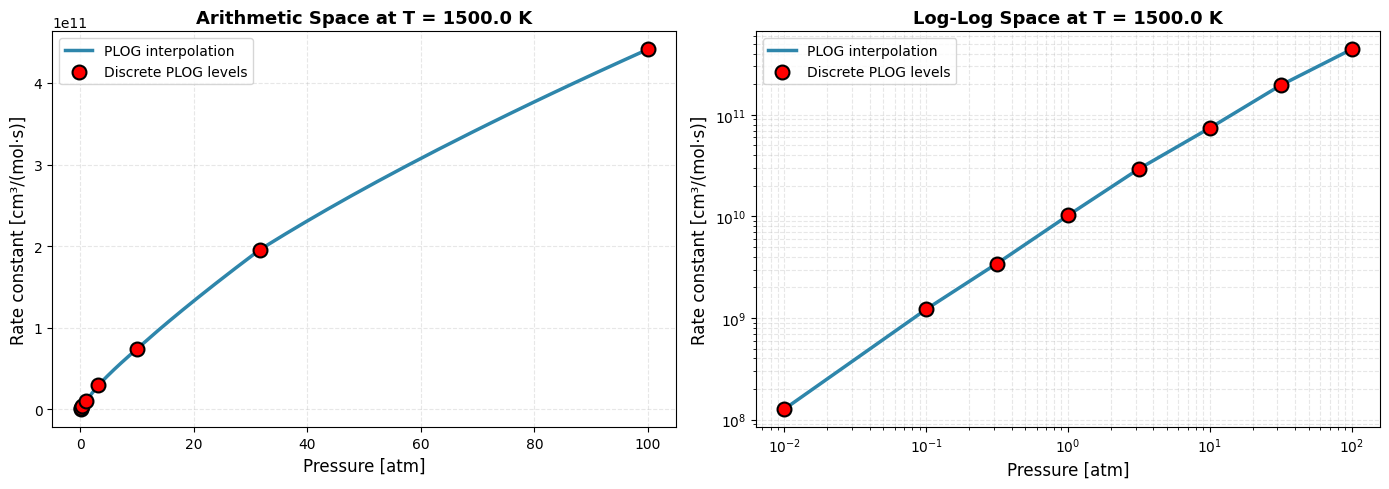

Note: In log-log space (right plot), the interpolation appears linear between discrete points.


In [5]:
# --------------------------------------------------------
# Select a representative temperature
T_fixed = 1500.0

# --------------------------------------------------------
# Get discrete PLOG pressure levels and their rate constants
P_discrete = jnp.array([float(p) for p in reaction.p_levels])
k_discrete = jnp.array([reaction.rate_constant(T_fixed, p) for p in P_discrete])

# --------------------------------------------------------
# Create fine pressure grid for interpolation
P_fine = jnp.logspace(jnp.log10(P_discrete[0]), jnp.log10(P_discrete[-1]), 200)
k_interpolated = reaction.rate_constant(T_fixed, P_fine)

# --------------------------------------------------------
# Visualize interpolation in different spaces
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Arithmetic space (shows curvature)
ax1.plot(P_fine, k_interpolated, linewidth=2.5, color="#2E86AB", label="PLOG interpolation")
ax1.scatter(
    P_discrete,
    k_discrete,
    s=100,
    color="red",
    zorder=10,
    marker="o",
    edgecolors="black",
    linewidth=1.5,
    label="Discrete PLOG levels",
)
ax1.set_xlabel("Pressure [atm]", fontsize=12)
ax1.set_ylabel("Rate constant [cm³/(mol·s)]", fontsize=12)
ax1.set_title(f"Arithmetic Space at T = {T_fixed} K", fontsize=13, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, linestyle="--")

# Plot 2: Log-log space (linear interpolation)
ax2.loglog(P_fine, k_interpolated, linewidth=2.5, color="#2E86AB", label="PLOG interpolation")
ax2.scatter(
    P_discrete,
    k_discrete,
    s=100,
    color="red",
    zorder=10,
    marker="o",
    edgecolors="black",
    linewidth=1.5,
    label="Discrete PLOG levels",
)
ax2.set_xlabel("Pressure [atm]", fontsize=12)
ax2.set_ylabel("Rate constant [cm³/(mol·s)]", fontsize=12)
ax2.set_title(f"Log-Log Space at T = {T_fixed} K", fontsize=13, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, linestyle="--", which="both")

plt.tight_layout()
plt.show()

print(f"Note: In log-log space (right plot), the interpolation appears linear between discrete points.")

## Pressure Dependence at Multiple Temperatures

PLOG reactions exhibit complex pressure dependence that varies with temperature. At low temperatures, pressure effects may be more pronounced, while at high temperatures, the rate constant may become less pressure-sensitive.

This behavior is crucial for modeling:
- High-pressure combustion systems
- Atmospheric chemistry at different altitudes
- Shock tube experiments across pressure ranges

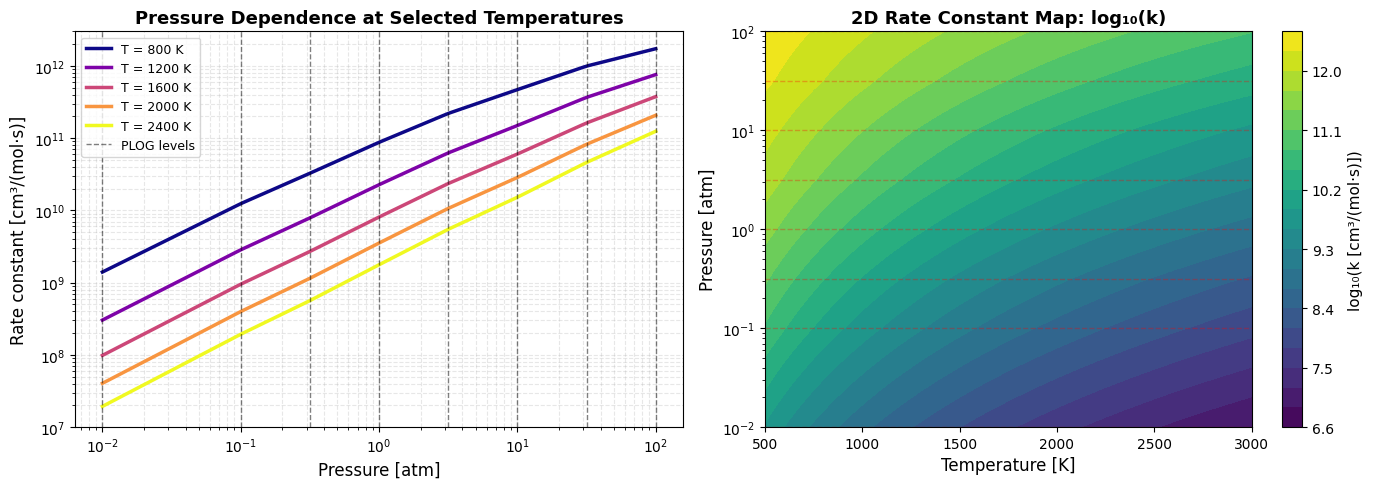

In [6]:
# --------------------------------------------------------
# Select representative temperatures
T_select = jnp.array([800, 1200, 1600, 2000, 2400])

# --------------------------------------------------------
# Create fine pressure grid for smooth curves
P_fine = jnp.logspace(-2, 2, 100)

# --------------------------------------------------------
# Visualize pressure dependence at multiple temperatures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors_T = plt.cm.plasma(jnp.linspace(0, 1, len(T_select)))

# Plot 1: k(P) at different temperatures
for i, T in enumerate(T_select):
    k_T = reaction.rate_constant(T, P_fine)
    ax1.loglog(P_fine, k_T, linewidth=2.5, label=f"T = {T:.0f} K", color=colors_T[i])

# Mark the discrete pressure levels
P_discrete = jnp.array([float(p) for p in reaction.p_levels])
ax1.vlines(P_discrete, ymin=1e7, ymax=1e13, linestyle="--", alpha=0.5, color="black", linewidth=1, label="PLOG levels")

ax1.set_xlabel("Pressure [atm]", fontsize=12)
ax1.set_ylabel("Rate constant [cm³/(mol·s)]", fontsize=12)
ax1.set_title("Pressure Dependence at Selected Temperatures", fontsize=13, fontweight="bold")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, linestyle="--", which="both")
ax1.set_ylim([1e7, 3e12])

# Plot 2: 2D heatmap of k(T, P)
T_grid = jnp.linspace(500, 3000, 100)
P_grid = jnp.logspace(-2, 2, 100)
k_2d = reaction.rate_constant(T_grid, P_grid)

# Create meshgrid for plotting
T_mesh, P_mesh = jnp.meshgrid(T_grid, P_grid)

c = ax2.contourf(T_mesh, P_mesh, jnp.log10(k_2d), levels=20, cmap="viridis")
ax2.set_xlabel("Temperature [K]", fontsize=12)
ax2.set_ylabel("Pressure [atm]", fontsize=12)
ax2.set_yscale("log")
ax2.set_title("2D Rate Constant Map: log₁₀(k)", fontsize=13, fontweight="bold")

# Add discrete pressure level markers
for p in P_discrete:
    ax2.axhline(p, color="red", linestyle="--", alpha=0.3, linewidth=1)

cbar = plt.colorbar(c, ax=ax2)
cbar.set_label("log₁₀(k [cm³/(mol·s)])", fontsize=11)

plt.tight_layout()
plt.show()